In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Step 3: Load the CSV file
# Replace the filename if needed
df = pd.read_csv("https://raw.githubusercontent.com/baren-kumar/ML-for-DS/refs/heads/main/home_appliance_segmentation_dataset.csv")


In [4]:
df

,Customer_ID,Age,Monthly_Income_USD,Annual_Appliance_Spend_USD,Purchase_Frequency_Per_Year,Smart_Feature_Interest_1_10,Energy_Saving_Interest_1_10,Preferred_Appliance_Item,Segment_Label
0,C1001,42,2256,132,3,2,4,Fan,Budget Buyers
1,C1002,45,2219,466,1,4,3,Electric Kettle,Budget Buyers
2,C1003,24,2695,239,1,2,7,Mixer Grinder,Budget Buyers
3,C1004,29,3639,421,3,1,4,Mixer Grinder,Budget Buyers
4,C1005,32,2938,199,2,3,3,Electric Kettle,Budget Buyers
...,...,...,...,...,...,...,...,...,...
115,C1116,33,6645,1380,5,6,8,Inverter AC,Eco Conscious
116,C1117,32,6713,633,2,7,9,Inverter AC,Eco Conscious
117,C1118,42,7956,509,3,5,10,Induction Cooker,Eco Conscious
118,C1119,26,4833,642,5,8,10,Air Purifier,Eco Conscious


In [6]:
# Step 5: Define input features and target
X = df.drop("Segment_Label", axis=1)
y = df["Segment_Label"]

In [7]:
# Step 6: Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nNumeric columns:", list(numeric_features))
print("Categorical columns:", list(categorical_features))


Numeric columns: ['Age', 'Monthly_Income_USD', 'Annual_Appliance_Spend_USD', 'Purchase_Frequency_Per_Year', 'Smart_Feature_Interest_1_10', 'Energy_Saving_Interest_1_10']
Categorical columns: ['Customer_ID', 'Preferred_Appliance_Item']


In [8]:
# Step 7: Create preprocessing steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [9]:
# Step 8: Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 9: Create KNN model pipeline
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [10]:
# Step 10: Train model
knn_model.fit(X_train, y_train)

# Step 11: Predict on test data
y_pred = knn_model.predict(X_test)

# Step 12: Evaluate model
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Model Accuracy: 0.9583333333333334

Classification Report:
                    precision    recall  f1-score   support

     Budget Buyers       1.00      1.00      1.00         6
     Eco Conscious       0.86      1.00      0.92         6
 Family Essentials       1.00      1.00      1.00         6
Smart Home Premium       1.00      0.83      0.91         6

          accuracy                           0.96        24
         macro avg       0.96      0.96      0.96        24
      weighted avg       0.96      0.96      0.96        24


Confusion Matrix:
[[6 0 0 0]
 [0 6 0 0]
 [0 0 6 0]
 [0 1 0 5]]


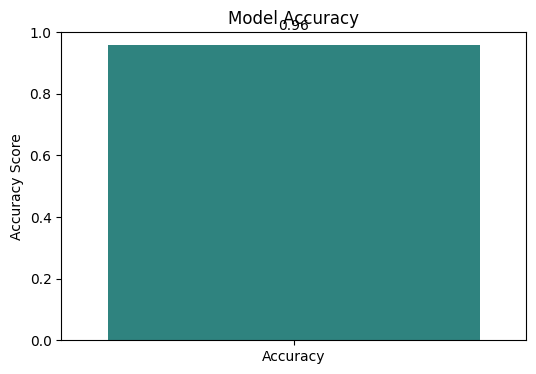

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.barplot(x=['Accuracy'], y=[accuracy], palette='viridis', hue=['Accuracy'], legend=False)
plt.title('Model Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.text(0, accuracy + 0.05, f'{accuracy:.2f}', ha='center')
plt.show()

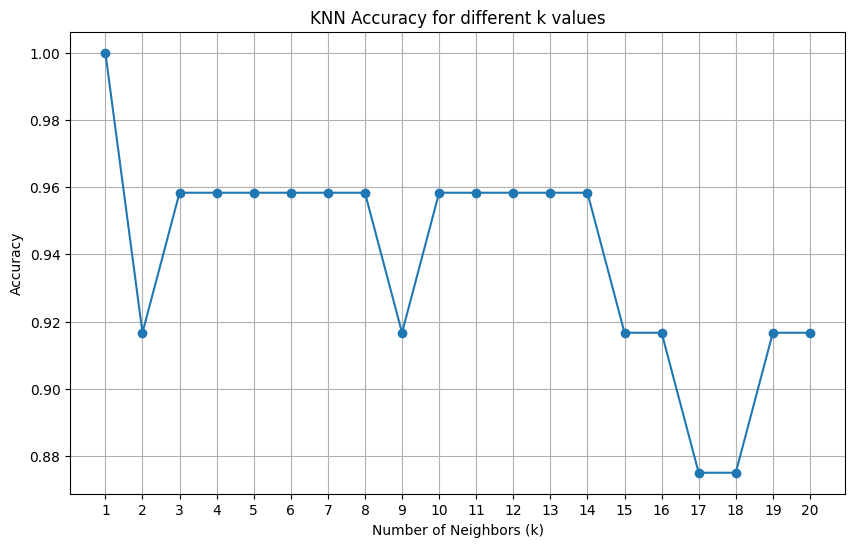


Optimum k value: 1
Maximum accuracy for optimum k: 1.00


In [15]:
# Step 14: Find optimum k values using different k values
k_range = range(1, 21) # Test k from 1 to 20
accuracies = []

for k in k_range:
    knn_model_k = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_model_k.fit(X_train, y_train)
    y_pred_k = knn_model_k.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='-')
plt.title('KNN Accuracy for different k values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Find the optimum k
optimum_k_index = np.argmax(accuracies)
optimum_k = k_range[optimum_k_index]
max_accuracy = accuracies[optimum_k_index]

print(f"\nOptimum k value: {optimum_k}")
print(f"Maximum accuracy for optimum k: {max_accuracy:.2f}")

In [12]:
# Step 13: Predict for a new customer
new_customer = pd.DataFrame([
    {
        "Customer_ID": "C9999", # Adding a dummy Customer_ID
        "Age": 32,
        "Monthly_Income_USD": 45000,
        "Annual_Appliance_Spend_USD": 1200,
        "Purchase_Frequency_Per_Year": 5,
        "Smart_Feature_Interest_1_10": 8,
        "Energy_Saving_Interest_1_10": 7,
        "Preferred_Appliance_Item": "Refrigerator"
    }
])

prediction = knn_model.predict(new_customer)
print("\nPredicted Segment for New Customer:", prediction[0])


Predicted Segment for New Customer: Smart Home Premium
